Source: Fahey,E. (2019, 26 June) The German Tank Problem [blog]  https://www.eadan.net/blog/german-tank-problem/
The German tank problem relates to a WWII story of how allies estimated German tank production numbers from capuring or observing tanks.

The Allies recorded the serial numbers on tanks captured. Looking at this data it is beleived the Germans numbered parts in the order they came off the production line. Using these serial numbers from a small numbers of captured tanks, the statisticians accurately estimated the total number of tanks that were produced!


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pymc3 as pm



In [2]:
pip install git+https://github.com/pymc-devs/pymc3

  Cloning https://github.com/pymc-devs/pymc3 to /tmp/pip-req-build-f6l7d0nl
  Running command git clone -q https://github.com/pymc-devs/pymc3 /tmp/pip-req-build-f6l7d0nl
  Created wheel for pymc3: filename=pymc3-3.9.3-cp36-none-any.whl size=90027308 sha256=86cd8c5f71c22439b17d421ca1c89c818b32d3f35a9a67f02a93a81a733620b4
  Stored in directory: /tmp/pip-ephem-wheel-cache-he43d18g/wheels/a1/e3/71/a696f2af0dd40bccc0ce672d616d21cc9dd90dbdd3f03242f4
Successfully built pymc3


In [3]:
pip install git+git://github.com/arviz-devs/arviz.git

  Cloning git://github.com/arviz-devs/arviz.git to /tmp/pip-req-build-boabuqiw
  Running command git clone -q git://github.com/arviz-devs/arviz.git /tmp/pip-req-build-boabuqiw
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
    Preparing wheel metadata ... done
  Created wheel for arviz: filename=arviz-0.9.0-cp36-none-any.whl size=2143463 sha256=0517157862269497bd6d0a0db100a1205e6362dda91a1d5328056389bf12e626
  Stored in directory: /tmp/pip-ephem-wheel-cache-7mgffscc/wheels/a5/04/05/bff2d46cd1c6506f627675722c196cfb3f657296e6e3bfaf57
Successfully built arviz


For a simulation assume 1,000 tanks in total, numbered sequentially from 1 to 1000. Now imagine capturing 15 tanks at random. Spin up 100,000 parallel universes in our computer to simulate this scenario.

In [4]:
num_tanks = 1000
num_captured = 15
serial_numbers = np.arange(1, num_tanks + 1)
num_simulations = 100_000

def capture_tanks(serial_numbers, n):
     """Capture `n` tanks, uniformly, at random."""
     return np.random.choice(serial_numbers, n, replace=False)

simulations = [
    capture_tanks(serial_numbers, num_captured)
    for _ in range(num_simulations)
]
simulations

[array([ 60, 387, 383, 685, 216, 563, 852, 988, 280, 230, 701, 506,  23,
         58, 848]),
 array([834, 842, 846, 128,   6, 454,   8,  87, 242, 390, 399, 618, 873,
        749, 967]),
 array([164, 648, 460, 329, 223, 722,  16, 907, 602, 310, 940, 450, 128,
         73, 861]),
 array([437, 270, 762, 680, 108, 672, 605, 168, 257, 839, 622, 961, 651,
        777,  69]),
 array([576, 536, 783, 117, 155,   8, 816, 602, 936, 637, 476, 525, 671,
        919, 874]),
 array([269,  37, 104, 423, 220, 716, 489, 444, 421, 521, 204, 449, 150,
        960, 136]),
 array([ 37, 472, 866, 864, 790, 907, 888, 985, 648, 959, 120, 334, 656,
        312, 455]),
 array([809, 782, 365, 199, 733, 427, 415, 223, 881, 669, 771, 334, 787,
        284, 781]),
 array([708, 807, 593, 945,  71,  91, 661, 634, 406, 624, 365, 104, 961,
        787, 809]),
 array([758, 834, 813, 715, 842, 681, 783, 417, 918, 604, 285, 553, 899,
        953, 433]),
 array([901, 500, 431,  81, 967, 302, 106, 579, 292, 362, 907, 404, 35

First estimator start with a simple estimate for the total number of tanks — the maximum serial number among the captured tanks.

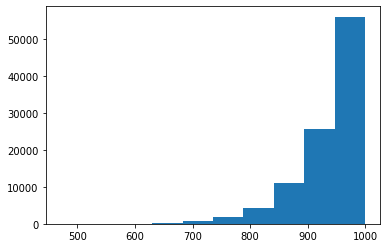

In [5]:
first_estimates = [max(s) for s in simulations]

plt.hist(first_estimates)
avg_first_estimates = np.mean(first_estimates)

This estimator will almost always under-estimate total number of tanks. Here, the average estimate across all simulations is 939. This is a biased estimator with the expected value of the estimate does not match the true value of the total number of tanks.

Adjust the estimator taking more information into account? One characteristic is the spacing between the serial numbers of captured tanks. Since the tanks are captured uniformly at random, if spacing is small, the maximum serial number of captured tanks should be close to the total number of tanks. Conversely, if spacing between the serial numbers is large, we should make a larger adjustment to the estimator. Here is the adjusted estimator. 

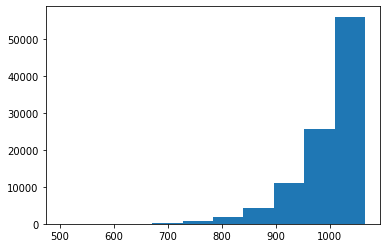

In [6]:
def max_plus_avg_spacing(simulation):
    m = max(simulation)
    avg_spacing = (m / num_captured) - 1 
    return m + avg_spacing

new_estimates = [max_plus_avg_spacing(s) for s in simulations]

plt.hist(new_estimates)
avg_new_estimates = np.mean(new_estimates)

Average estimate across all simulations exactly matches the total number of tanks, 1000.The revised estimator is an unbiased estimator.

In [7]:
print(np.std(first_estimates))

58.08900919010067


In [8]:
print(np.std(new_estimates))

61.96160980277404


For the first estimator the standard deviation is 57, but for the adjusted estimator 62. The first estimator underestimates on average with tighter distribution. The adjusted estimator is unbiased with more variability in distribution. This is an example of the bias-variance trade-off in action.

Where do these estimators come from? No “correct” way to estimate a statistical quantity, just strategies with different benefits and trade-offs. The first estimator, the maximum serial number of the captured tanksmaximum likelihood estimate (MLE), and its adjustment is the so-called minimum variance unbiased estimator (MVUE). Technical details on proof relating to parameter estimation is available at https://laurentlessard.com/bookproofs/tank-counting/

In [9]:
captured=[499, 505, 190, 427, 185, 572, 818, 721, 
            912, 302, 765, 231, 547, 410, 884]

In [10]:
print(max_plus_avg_spacing(captured))

971.8


These estimators are somewhat ad-hoc. What if we could reverse or rather invert the simulation? Starting from the observed data (the captured serial numbers), simulate the parameters which generate the data according to a probabilistic model. We achieve this using probabilistic programming. More specifically, our code uses the python library pymc3 (https://docs.pymc.io/).

With probabilistic programming, instead of setting a fixed value for the total number of tanks we can define a prior distribution that encodes our apriori beliefs and knowledge about the parameter(s) of interest.For our tank problem a reasonable prior distribution for the number of tanks is a DiscreteUniform with a lower bound at the maximum serial number of the captured tanks ( the number of tanks can't be lower than this), and an upper bound of a large number e.g. 2000.

With the prior, we need to define the data-generating distribution, (likelihood). This is basically the capture_tanks function from earlier, that we re-define as another DiscreteUniform distribution using pymc3.

In [11]:
with pm.Model():
    num_tanks = pm.DiscreteUniform(
        "num_tanks", 
	lower=max(captured), 
	upper=2000
    )
    likelihood = pm.DiscreteUniform(
        "observed", 
	lower=1, 
	upper=num_tanks, 
	observed=captured
    )
    posterior = pm.sample(10000, tune=1000)

Sequential sampling (2 chains in 1 job)
Metropolis: [num_tanks]


Sampling 2 chains for 1_000 tune and 10_000 draw iterations (2_000 + 20_000 draws total) took 4 seconds.
The number of effective samples is smaller than 10% for some parameters.


The result of running this model through pymc3 is a large number of samples from the posterior distribution — the probability distribution for the number of tanks given the observed data. The key here is distribution, rather than a point estimator. We have a distribution that tells us the most credible values for the number of tanks.

/usr/local/lib/python3.6/dist-packages/arviz/utils.py:654: UserWarning: Keyword argument credible_interval has been deprecated Please replace with hdi_prob
  ("Keyword argument credible_interval has been deprecated " "Please replace with hdi_prob"),
/usr/local/lib/python3.6/dist-packages/arviz/data/io_pymc3.py:89: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  FutureWarning,


array([<matplotlib.axes._subplots.AxesSubplot object at 0x7fbe89070048>],
      dtype=object)

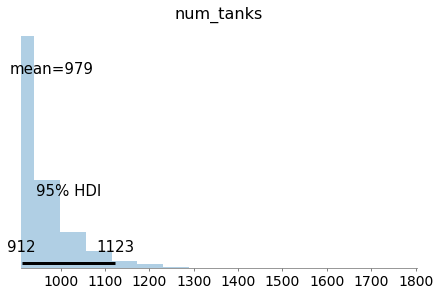

In [12]:
pm.plot_posterior(posterior, credible_interval=0.95)

Visualising the posterior distribution, we see the mean value is 981. This value alone is a pretty good estimate for the number of tanks. But we can also use the distribution. For example, the 95% highest posterior density (HPD) interval tells us there is a 95% probability that the number of tanks lies somewhere between 912 and 1,131.

Probabilistic programming is a very powerful tool. A relatively young field, but is starting to become more popular especially due to recent algorithmic advances and an abundance of computational resources. 